# LLAT polar — 訓練分析

| | baseline(學姊) | mine(本次) |
|---|---|---|
| 變數 | u / v | **vt / vr** |
| 網格 | R=201(Δr 0.05°) | **R=41(Δr 0.25°)** |
| 精度 | fp32 | **bf16-mixed** |
| 等效批次 | 4 | **32(8×H200)** |
| max_steps | 1,600,000(只跑 15.8%) | **105,000(跑滿)** |
| 峰值 LR | 4e-4 | 4e-4 |
| 牆鐘 | 8.32 天 | **6.7 小時** |

⚠️ **val_loss 不可直接比較** —— 變數表與網格不同,loss 的尺度與平均對象不一樣。
可直接比較的是:**LR 是否完成退火、訓練穩定性、吞吐**。

In [ ]:
import csv, numpy as np, matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": .3})
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
# 對數座標的刻度標籤(10^-1 之類)走 mathtext,它有【自己的】字型設定。
# 若讓它沿用 font.sans-serif,微軟正黑體沒有 U+2212 減號,10^-1 會被畫成
# 「10^x1」—— 圖看起來就像壞掉。強制 mathtext 用 DejaVu。
plt.rcParams["mathtext.fontset"] = "dejavusans"


def load(path):
    """讀 curves.csv。

    CSV 有兩種空值,載入成陣列後【長得一樣但意義相反】:
      - 空字串   → 該 step 沒有記錄這個指標(取樣頻率不同,正常)
      - "nan"    → 有記錄,但值就是 NaN(訓練壞掉了)
    兩者都會變成 np.nan,所以另外存一份「明確是 NaN」的遮罩,
    否則 fp16 的崩潰點會被誤判成第一個沒取樣到的 step。
    """
    out, explicit = {}, {}
    with open(path, newline="") as f:
        rd = csv.DictReader(f)
        for c in rd.fieldnames:
            out[c], explicit[c] = [], []
        for r in rd:
            for c in rd.fieldnames:
                raw = r[c]
                miss = raw in ("", None)
                v = np.nan if miss else float(raw)
                out[c].append(v)
                explicit[c].append((not miss) and v != v)
    d = {c: np.array(v) for c, v in out.items()}
    d["_explicit_nan"] = {c: np.array(m) for c, m in explicit.items()}
    return d


def ser(d, col):
    """回傳該欄非 NaN 的 (step, value)"""
    m = ~np.isnan(d[col])
    return d["step"][m], d[col][m]


mine = load("run_mine_curves.csv")
base = load("run_baseline_curves.csv")

for n, d in (("mine", mine), ("baseline", base)):
    s, v = ser(d, "val_loss")
    print(f"{n:9s} val_loss {len(v):5d} 點  首 {v[0]:.5f}  末 {v[-1]:.5f}  "
          f"最佳 {v.min():.5f} @ step {int(s[v.argmin()])}")

print("\n⚠️ 各組的 val 取樣密度差很多(每個 epoch 一點):")
print("   原始 231 點 / 231 epochs  ←  曲線看起來鋸齒狀")
print("   短診斷 29 點 / 30 epochs  ←  曲線看起來平滑,這是【取樣稀疏】不是資料異常")

## 圖 1:損失曲線(對數座標才看得到 spike)

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

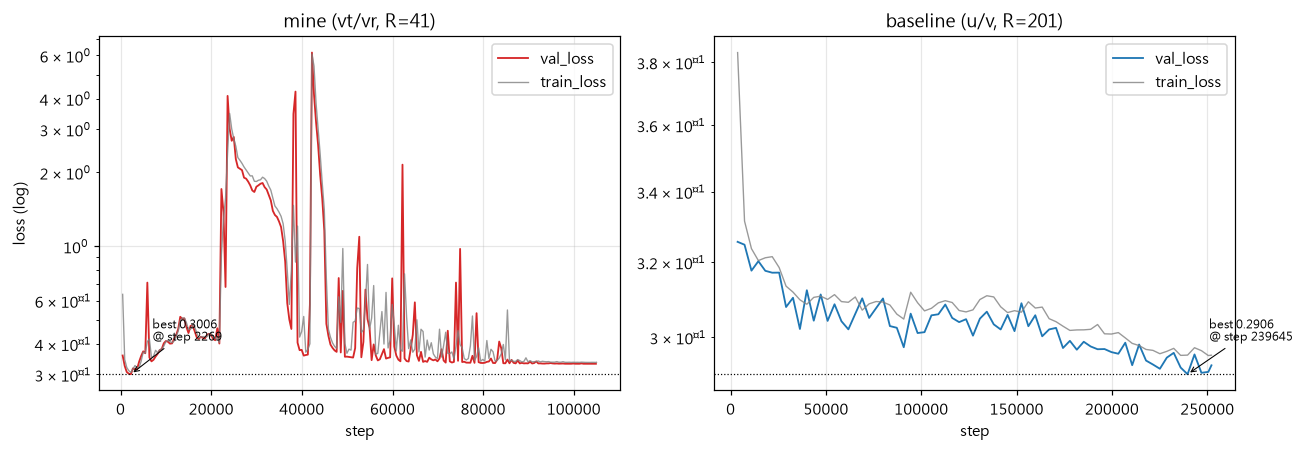

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for i, (n, d, c) in enumerate([("mine (vt/vr, R=41)", mine, "tab:red"),
                               ("baseline (u/v, R=201)", base, "tab:blue")]):
    s, v = ser(d, "val_loss")
    st, vt = ser(d, "train_loss_epoch")
    ax[i].semilogy(s, v, c=c, lw=1.2, label="val_loss")
    ax[i].semilogy(st, vt, c="gray", lw=.9, alpha=.8, label="train_loss")
    ax[i].axhline(v.min(), ls=":", c="k", lw=.8)
    ax[i].annotate("best %.4f\n@ step %d" % (v.min(), s[v.argmin()]),
                   (s[v.argmin()], v.min()), textcoords="offset points",
                   xytext=(14, 22), fontsize=8,
                   arrowprops=dict(arrowstyle="->", lw=.7))
    ax[i].set_title(n)
    ax[i].set_xlabel("step")
    ax[i].legend()

ax[0].set_ylabel("loss (log)")
plt.tight_layout()
plt.show()

## 圖 2:學習率退火對照 —— **最關鍵的一張**

baseline 把 `max_steps` 設 1.6M 卻只跑到 252k(15.8%),cosine 只走了開頭一小段,
**結束時 LR 仍在峰值的 94%**;本次把 `max_steps` 設成跑得完的值,退火完整走到 0。

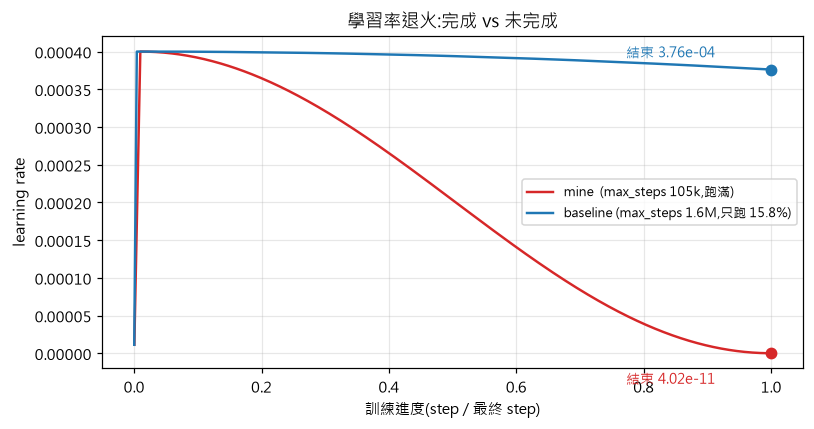

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4))

for n, d, c, dy in [("mine  (max_steps 105k,跑滿)", mine, "tab:red", -20),
                    ("baseline (max_steps 1.6M,只跑 15.8%)", base, "tab:blue", 8)]:
    s, v = ser(d, "lr-AdamW")
    ax.plot(s / s.max(), v, c=c, lw=1.6, label=n)
    ax.scatter([1.0], [v[-1]], c=c, s=45, zorder=5)
    ax.annotate("結束 %.2e" % v[-1], (1.0, v[-1]), textcoords="offset points",
                xytext=(-95, dy), fontsize=9, color=c)

ax.set_xlabel("訓練進度(step / 最終 step)")
ax.set_ylabel("learning rate")
ax.set_title("學習率退火:完成 vs 未完成")
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

## 圖 3:LR 與訓練穩定性

把本次每個驗證點的 val_loss 對「當時的 LR」作圖 —— spike 隨 LR 下降而消失,
可讀出經驗穩定閾值,作為下一次實驗設定峰值 LR 的依據。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

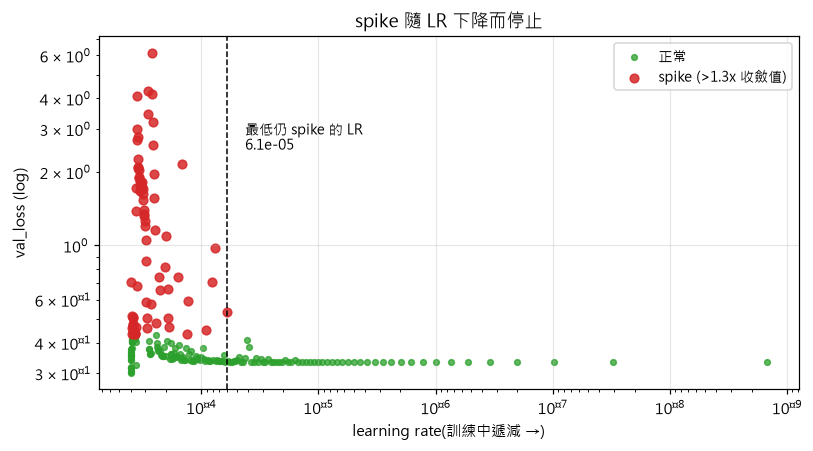

收斂水準            : 0.33211
spike 次數          : 76 / 231
最低仍 spike 的 LR  : 6.06e-05
→ 下次峰值 LR 建議 <= 6e-05


In [4]:
sv, v = ser(mine, "val_loss")
sl, l = ser(mine, "lr-AdamW")
lr_at = np.interp(sv, sl, l)          # 每個驗證點當時的 LR

lvl = np.median(v[-30:])              # 收斂後的水準
spike = v > lvl * 1.3

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(lr_at[~spike], v[~spike], s=14, c="tab:green", alpha=.75, label="正常")
ax.scatter(lr_at[spike], v[spike], s=32, c="tab:red", alpha=.85,
           label="spike (>1.3x 收斂值)")

if spike.any():
    thr = lr_at[spike].min()
    ax.axvline(thr, ls="--", c="k", lw=1)
    ax.annotate("最低仍 spike 的 LR\n%.1e" % thr, (thr, v.max() * .4),
                xytext=(12, 0), textcoords="offset points", fontsize=9)

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("learning rate(訓練中遞減 →)")
ax.set_ylabel("val_loss (log)")
ax.set_title("spike 隨 LR 下降而停止")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("收斂水準            : %.5f" % lvl)
print("spike 次數          : %d / %d" % (spike.sum(), len(v)))
if spike.any():
    print("最低仍 spike 的 LR  : %.2e" % lr_at[spike].min())
    print("→ 下次峰值 LR 建議 <= %.0e" % lr_at[spike].min())

## 圖 4:逐變數 val_RMSE

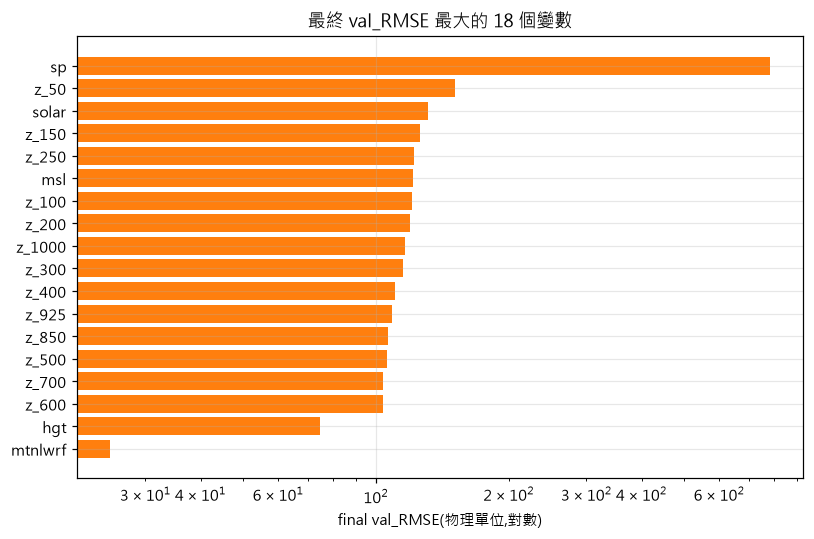

注意:各變數單位不同(Pa / m2s-2 / K ...),不可跨變數比大小。


In [5]:
per = {}
with open("run_mine_per_var.csv", newline="") as f:
    for r in csv.DictReader(f):
        per.setdefault(r["tag"], []).append((int(r["step"]), float(r["value"])))

final = {t: sorted(p)[-1][1] for t, p in per.items() if t.startswith("val_RMSE/")}
top = sorted(final.items(), key=lambda x: -x[1])[:18]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh([t.replace("val_RMSE/", "") for t, _ in top][::-1],
        [v for _, v in top][::-1], color="tab:orange")
ax.set_xscale("log")
ax.set_xlabel("final val_RMSE(物理單位,對數)")
ax.set_title("最終 val_RMSE 最大的 18 個變數")
plt.tight_layout()
plt.show()

print("注意:各變數單位不同(Pa / m2s-2 / K ...),不可跨變數比大小。")

## 摘要表(可貼進投影片)

In [3]:
def summ(d):
    s, v = ser(d, "val_loss")
    _, l = ser(d, "lr-AdamW")
    _, e = ser(d, "epoch")
    h = d["hours"][~np.isnan(d["hours"])]
    return dict(best=v.min(), bstep=int(s[v.argmin()]), final=v[-1],
                ep=int(e.max()), st=int(s.max()), lr0=l.max(), lr1=l[-1],
                hr=h.max() if len(h) else float("nan"))


a, b = summ(mine), summ(base)
rows = [
    ("最佳 val_loss", "%.5f (step %d)" % (a["best"], a["bstep"]),
                      "%.5f (step %d)" % (b["best"], b["bstep"])),
    ("最終 val_loss", "%.5f" % a["final"], "%.5f" % b["final"]),
    ("epochs", str(a["ep"]), str(b["ep"])),
    ("steps", "{:,}".format(a["st"]), "{:,}".format(b["st"])),
    ("牆鐘(小時)", "%.1f" % a["hr"], "%.1f" % b["hr"]),
    ("LR 峰值→結束", "%.1e → %.1e" % (a["lr0"], a["lr1"]),
                     "%.1e → %.1e" % (b["lr0"], b["lr1"])),
    ("LR 退火完成度", "%.0f%%" % ((1 - a["lr1"] / a["lr0"]) * 100),
                      "%.0f%%" % ((1 - b["lr1"] / b["lr0"]) * 100)),
]

w = max(len(r[0]) for r in rows)
print("%-*s  %26s  %26s" % (w, "", "mine (vt/vr, R=41)", "baseline (u/v, R=201)"))
print("-" * (w + 58))
for k, x, y in rows:
    print("%-*s  %26s  %26s" % (w, k, x, y))
print()
print("⚠️ val_loss 不可直接比較(變數表與網格不同)。")
print("   可比的是:LR 退火完成度、訓練穩定性、吞吐。")

                     mine (vt/vr, R=41)       baseline (u/v, R=201)
---------------------------------------------------------------------
最佳 val_loss         0.30065 (step 2269)       0.29061 (step 239645)
最終 val_loss                     0.33168                     0.29284
epochs                              231                          69
steps                           104,873                     252,160
牆鐘(小時)                              6.7                       199.6
LR 峰值→結束              4.0e-04 → 4.0e-11           4.0e-04 → 3.8e-04
LR 退火完成度                           100%                          6%

⚠️ val_loss 不可直接比較(變數表與網格不同)。
   可比的是:LR 退火完成度、訓練穩定性、吞吐。


---

# 短診斷(2026-08-04)

原始訓練梯度中位數 **3.8e6**、95.6% 的步驟被裁剪。跑兩組短診斷試圖歸因:

| | Job | 精度 | 峰值 LR | `max_steps` | 牆鐘 |
|---|---|---|---|---|---|
| 原始 | 233052 | bf16-mixed | 4e-4 | 105,000 | 6.7 h |
| **診斷 A** | 234729 | **fp32** | 4e-4 | **13,600** | 79 min |
| **診斷 B** | 234730 | bf16-mixed | **5e-5** | **13,600** | 53 min |

## 圖 5:梯度範數三者對照

左圖用全程資料會有長度造成的假象(原始跑 105k、診斷只跑 13.6k),
右圖把原始訓練**裁切到同一段 step** 才是公平比較。

(略過,檔案不存在:prod_lr5e-5_curves.csv)
(略過,檔案不存在:prod_fp32_curves.csv)


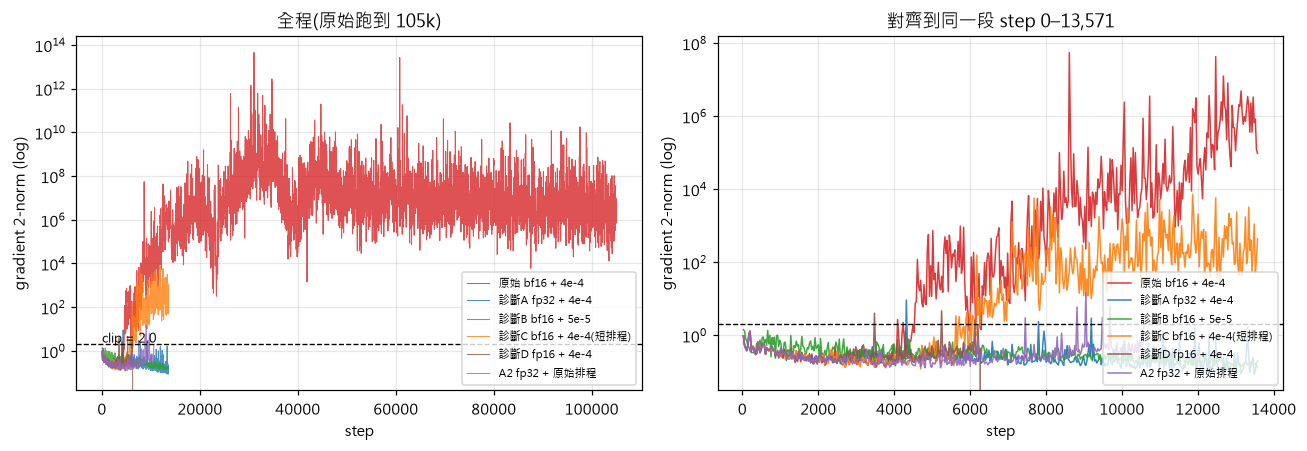


同一段 step 0–13571 的比較(裁掉較長的 run,避免長度造成假象)
                                  總步數      有效點       梯度中位         梯度最大     >2.0  備註
------------------------------------------------------------------------------------------------
原始 bf16 + 4e-4                 104999      468      147.2    5.515e+07    66.2%  
診斷A fp32 + 4e-4                 13599      468     0.2275        9.229     0.6%  
診斷B bf16 + 5e-5                 13599      468     0.2812        1.427     0.0%  
診斷C bf16 + 4e-4(短排程)            13599      468      9.843         7099    56.2%  
診斷D fp16 + 4e-4                 13599      221     0.2864        4.705     1.4%  有效點只到 6495
A2 fp32 + 原始排程                  10574      365     0.2548         14.6     1.4%  有效點只到 10574

「總步數」是實際跑到第幾步;「有效點」是窗口內非 NaN 的取樣數。
fp16 兩者落差很大 —— 它跑滿 13,571 步,但 step 6,321 之後的紀錄全是 NaN。

⚠️ 兩種 16-bit 從相反方向失敗:
   bf16(尾數 8 bits,指數 8 bits)範圍夠、精度不足 → 梯度【漸進】爬升到 1e4
   fp16(尾數 11 bits,指數 5 bits)精度夠、範圍不足 → 【突然】溢位成 NaN


In [30]:
import os

# 要比較的實驗:(顯示名稱, CSV 檔名, 顏色)。檔案不存在就自動略過,
# 所以新的 run 跑完後只要把 curves.csv 放進本目錄改成對應檔名即可,程式不用動。
CANDIDATES = [
    ("原始 bf16 + 4e-4", None,                          "tab:red"),   # mine,cell 1 已載入
    ("診斷A fp32 + 4e-4", "diag_fp32_curves.csv",        "tab:blue"),
    ("診斷B bf16 + 5e-5", "diag_lr5e-5_curves.csv",      "tab:green"),
    ("診斷C bf16 + 4e-4(短排程)", "diag_C_curves.csv",   "tab:orange"),
    ("診斷D fp16 + 4e-4", "diag_fp16_curves.csv",        "tab:brown"),
    ("A2 fp32 + 原始排程", "diag_fp32_s105k_curves.csv", "tab:purple"),
    # ── 正式訓練(跑完後 scp 各自的 curves.csv 進來)──────────────────
    ("正式 bf16 + 5e-5", "prod_lr5e-5_curves.csv",       "tab:olive"),
    ("正式 fp32 + 4e-4", "prod_fp32_curves.csv",         "tab:cyan"),
]

RUNS = []
for n, path, c in CANDIDATES:
    if path is None:
        RUNS.append((n, mine, c))
    elif os.path.exists(path):
        RUNS.append((n, load(path), c))
    else:
        print("(略過,檔案不存在:%s)" % path)


def nan_onset(d, col="gradient_2norm"):
    """回傳「值明確變成 NaN」的第一個 step;沒有則 None。

    必須用 _explicit_nan 遮罩,不能直接看 np.isnan —— 後者連「該 step 沒取樣」
    也會算進去,會把崩潰點誤判成訓練最開頭。
    """
    m = d.get("_explicit_nan", {}).get(col)
    if m is None or not m.any():
        return None
    return int(d["step"][np.flatnonzero(m)[0]])


def mark_nan(a, step, colour, label):
    """把崩潰點標成【看得見】的樣子:虛線 + 帶白底的文字框。

    先前把文字放在資料座標 y=4、rotation=90,結果被曲線和圖例蓋住幾乎看不到。
    改成用 axes 座標固定貼在頂端,並加白底外框。
    """
    a.axvline(step, c=colour, ls=":", lw=1.8)
    a.annotate("NaN @ %d" % step, xy=(step, 1.0), xycoords=("data", "axes fraction"),
               xytext=(0, -12), textcoords="offset points",
               ha="center", va="top", fontsize=8.5, color=colour, fontweight="bold",
               bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=colour, lw=1))


# 診斷組的共同長度。用 min(各組步數) 會被 A2(因 max_time 只跑到 10,574)拉短,
# 而爆炸程度隨 step 增長,窗口一短就會低估原始那次的嚴重性。
CUT = 13571

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for n, d, c in RUNS:
    s, g = ser(d, "gradient_2norm")
    ax[0].semilogy(s, g, c=c, lw=.7, alpha=.8, label=n)
    m = s <= CUT
    ax[1].semilogy(s[m], g[m], c=c, lw=1.0, alpha=.9, label=n)
    nz = nan_onset(d)
    if nz is not None:
        mark_nan(ax[0], nz, c, n)
        if nz <= CUT:
            mark_nan(ax[1], nz, c, n)

for a_, t in zip(ax, ["全程(原始跑到 105k)", "對齊到同一段 step 0–%s" % f"{CUT:,}"]):
    a_.axhline(2.0, ls="--", c="k", lw=.9)
    a_.set_xlabel("step")
    a_.set_ylabel("gradient 2-norm (log)")
    a_.set_title(t)
# 左圖曲線集中在左半,圖例放右下;右圖曲線往右上爬,圖例必須放左上才不擋線
ax[0].legend(fontsize=7.5, loc="lower right")
ax[1].legend(fontsize=7.5, loc="upper left")
ax[0].annotate("clip = 2.0", (0, 2.4), fontsize=8.5)

plt.tight_layout()
plt.show()


print("\n同一段 step 0–%d 的比較(裁掉較長的 run,避免長度造成假象)" % CUT)
print("%-28s %8s %8s %10s %12s %8s  %s"
      % ("", "總步數", "有效點", "梯度中位", "梯度最大", ">2.0", "備註"))
print("-" * 96)
for n, d, _ in RUNS:
    s, g = ser(d, "gradient_2norm")
    seg = g[s <= CUT]
    total = int(d["step"].max())          # 實際跑到第幾步(含 NaN 之後)
    nz = nan_onset(d)
    note = "" if nz is None else "step %d 起 NaN,權重損壞" % nz
    if int(s.max()) < CUT:
        note = ("有效點只到 %d" % s.max()) + (";" + note if note else "")
    print("%-28s %8d %8d %10.4g %12.4g %7.1f%%  %s"
          % (n, total, len(seg), np.median(seg), seg.max(),
             100 * (seg > 2).mean(), note))

print("\n「總步數」是實際跑到第幾步;「有效點」是窗口內非 NaN 的取樣數。")
print("fp16 兩者落差很大 —— 它跑滿 13,571 步,但 step 6,321 之後的紀錄全是 NaN。")
print("\n⚠️ 兩種 16-bit 從相反方向失敗:")
print("   bf16(尾數 8 bits,指數 8 bits)範圍夠、精度不足 → 梯度【漸進】爬升到 1e4")
print("   fp16(尾數 11 bits,指數 5 bits)精度夠、範圍不足 → 【突然】溢位成 NaN")

## 圖 5b:損失狀態 —— 各組實際學到什麼程度

梯度告訴你**訓練有沒有壞掉**,損失才告訴你**模型有沒有學好**。兩者要分開看:
原始那次梯度中位 147(壞掉)但 val_loss 仍有 0.30065(還是學到了東西),
就是因為梯度裁剪把每一步壓成固定步長,模型仍在往前走,只是方向持續惡化。

**左圖(val_loss vs step)** 是絕對比較,但各組 `max_steps` 不同、退火進度不同,
step 相同不代表狀態相同。

**右圖(val_loss vs 當時的 LR)** 才是公平的比較軸:把橫軸換成「退火到哪裡了」,
不同長度的排程就能疊在一起看 —— **同樣退火到 1e-5 時,誰的 loss 比較低?**

> ⚠️ 跨「變數表/網格」的比較仍然無效(loss 是對標準化變數取平均,尺度不同)。
> 這裡所有極座標版的組別都是 vt/vr + R=41,**彼此之間可比**;
> `baseline`(u/v, R=201)不在此圖內,不要跨組比大小。

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))

for n, d, c in RUNS:
    s, v = ser(d, "val_loss")
    if not len(v):
        continue

    # 左:全程 —— 絕對比較,但各組長度不同
    ax[0].semilogy(s, v, c=c, lw=1.1, alpha=.9, label=n)
    ax[0].scatter([s[v.argmin()]], [v.min()], c=c, s=32, zorder=5)

    # 中:裁切到同一段 step —— 與圖 5 的右圖用【同一個窗口】,可以並排對讀
    m = s <= CUT
    if m.any():
        ax[1].semilogy(s[m], v[m], c=c, lw=1.3, alpha=.9, label=n)
        vm = v[m]
        ax[1].scatter([s[m][vm.argmin()]], [vm.min()], c=c, s=36, zorder=5)

    # 右:以「當時的 LR」為橫軸 —— 各組 max_steps 不同,step 無法對齊,
    # 但「退火到同一個 LR 時 loss 是多少」是可比的。
    sl, l = ser(d, "lr-AdamW")
    if len(l) > 1:
        lr_at = np.interp(s, sl, l)
        ok = lr_at > 0
        ax[2].loglog(lr_at[ok], v[ok], c=c, lw=1.1, alpha=.9, label=n)

    nz = nan_onset(d, "val_loss")
    if nz is not None:
        mark_nan(ax[0], nz, c, n)
        if nz <= CUT:
            mark_nan(ax[1], nz, c, n)

ax[0].set_xlabel("step"); ax[0].set_ylabel("val_loss (log)")
ax[0].set_title("全程(● = 該組最佳)")
ax[0].legend(fontsize=7, loc="upper right")

ax[1].set_xlabel("step"); ax[1].set_ylabel("val_loss (log)")
ax[1].set_title("對齊到同一段 step 0–%s" % f"{CUT:,}")
ax[1].legend(fontsize=7, loc="upper right")

ax[2].invert_xaxis()
ax[2].set_xlabel("learning rate(訓練中遞減 →)")
ax[2].set_ylabel("val_loss (log)")
ax[2].set_title("退火到同一個 LR 時,誰的 loss 較低")
ax[2].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()


print("%-28s %9s %8s %9s %9s %7s %7s"
      % ("", "最佳val", "@step", "最終val", "最終train", "gap", "spike"))
print("-" * 84)
for n, d, _ in RUNS:
    s, v = ser(d, "val_loss")
    st, tv = ser(d, "train_loss_epoch")
    if not len(v):
        continue
    lvl = np.median(v[-max(3, len(v) // 10):])         # 收斂水準
    spike = int((v > lvl * 1.3).sum())
    gap = v[-1] - tv[-1] if len(tv) else float("nan")
    print("%-28s %9.5f %8d %9.5f %9.5f %+7.4f %7d"
          % (n, v.min(), s[v.argmin()], v[-1], tv[-1] if len(tv) else np.nan,
             gap, spike))

print("\ngap = 最終 val − 最終 train。負值代表 val 比 train 還低 ⇒ 沒有過擬合")
print("      (本專案的驗證年份與訓練年份不同,且模型容量小,故 gap 為負屬正常)")
print("spike = val_loss > 1.3 × 收斂水準的次數 ⇒ 訓練穩定性的直接指標")
print("\n⚠️ val 每個 epoch 才記一點,所以短診斷只有 29 點、原始有 231 點。")
print("   短診斷的曲線看起來比較平滑是【取樣稀疏】,不是訓練比較平穩 ——")
print("   要看穩定性請用 spike 欄或圖 5 的梯度。")

## 圖 6:診斷的混淆變因 —— **這兩組其實都不是單變數對照**

兩個診斷都把 `max_steps` 105,000 → 13,600 以縮短時間。但 cosine 的長度來自
[`lightning_modules.py`](../models/lightning_modules.py#L229) 的

```python
training_steps = int(self.trainer.estimated_stepping_batches)
```

而 Lightning 定義 `estimated_stepping_batches = min(每epoch步數 × max_epochs, max_steps)`。
**所以改 `max_steps` 就等於改 LR 軌跡** —— 診斷 A 同時變動了「精度 + LR 軌跡」,
診斷 B 同時變動了「峰值 LR + LR 軌跡」,兩者都無法單獨歸因。

> ⚠️ 改用 `max_epochs` 限制**同樣無效**:上式取 min,壓縮效果一模一樣。
> 唯一不影響排程的停止條件是 **`max_time`**(由 Timer callback 執行,不進上式)。
> `experiments/diag_fp32_sched105k.yaml` 就是照這個設計寫的。

右圖顯示:在三者 LR 都還在峰值的窗口內,**梯度幾乎完全重疊**。
原始訓練的惡化發生在 step 4,000–5,000 之間,而那正是診斷組的 LR 開始明顯下降的時候。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

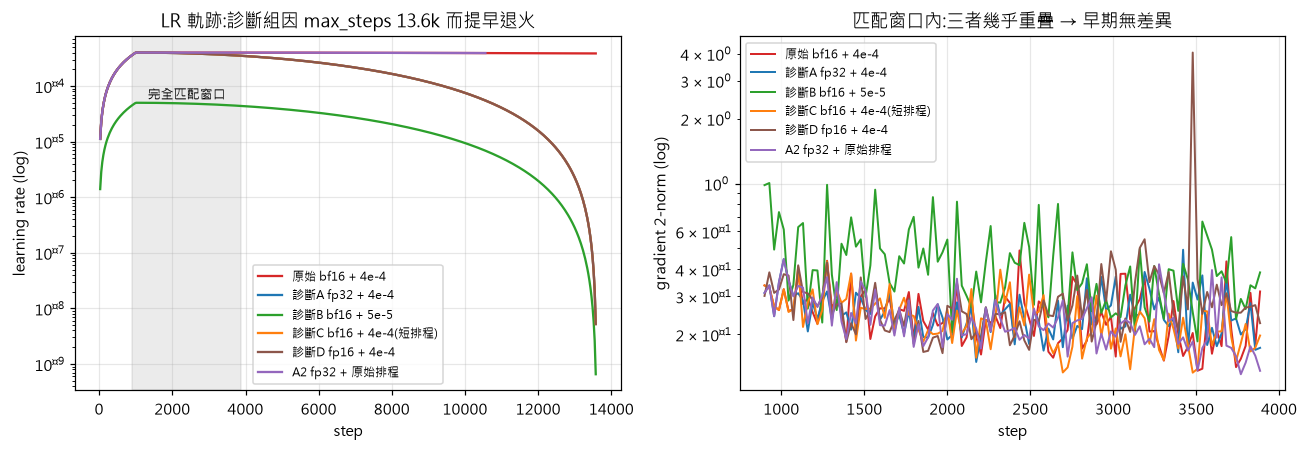

完全匹配窗口 step 898–3885(LR 都在峰值附近)
                             梯度中位         梯度最大
原始 bf16 + 4e-4             0.2416       0.4893
診斷A fp32 + 4e-4             0.244       0.4929
診斷B bf16 + 5e-5             0.393        1.005
診斷C bf16 + 4e-4(短排程)       0.2333       0.4349
診斷D fp16 + 4e-4            0.2601        4.047
A2 fp32 + 原始排程             0.2219       0.4463

原始訓練前 14k 步的逐千步演變(找出惡化的確切時點):
   step     0-999    中位     0.4174  最大       1.319
   step  1000-1999   中位     0.2612  最大      0.4383
   step  2000-2999   中位     0.2261  最大      0.4893
   step  3000-3999   中位     0.2042  最大      0.5686
   step  4000-4999   中位      2.254  最大       576.2  ← 跳升
   step  5000-5999   中位      72.15  最大       978.4
   step  6000-6999   中位      42.43  最大       877.3
   step  7000-7999   中位      231.8  最大   1.073e+04
   step  8000-8999   中位       3401  最大   5.515e+07
   step  9000-9999   中位       7308  最大   1.412e+05
   step 10000-10999  中位  1.102e+04  最大    3.55e+06
   step 11000-11999  中位  1.617e+04  最大   

In [20]:
# 左:同一段 step 內的 LR 軌跡 —— 看得出診斷組的排程被壓縮了
# 右:完全匹配的窗口(三者 LR 都還在峰值附近),梯度是否有差
LO, HI = 898, 3885                    # 診斷 A 的 LR 仍 > 3.5e-4 的區間

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for n, d, c in RUNS:
    s, l = ser(d, "lr-AdamW")
    m = s <= CUT
    ax[0].semilogy(s[m], l[m], c=c, lw=1.5, label=n)
ax[0].axvspan(LO, HI, color="k", alpha=.08)
ax[0].annotate("完全匹配窗口", ((LO + HI) / 2, 6e-5), ha="center", fontsize=8.5)
ax[0].set_xlabel("step")
ax[0].set_ylabel("learning rate (log)")
ax[0].set_title("LR 軌跡:診斷組因 max_steps 13.6k 而提早退火")
ax[0].legend(fontsize=8)

for n, d, c in RUNS:
    s, g = ser(d, "gradient_2norm")
    m = (s >= LO) & (s <= HI)
    ax[1].semilogy(s[m], g[m], c=c, lw=1.3, label=n)
ax[1].set_xlabel("step")
ax[1].set_ylabel("gradient 2-norm (log)")
ax[1].set_title("匹配窗口內:三者幾乎重疊 → 早期無差異")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


print("完全匹配窗口 step %d–%d(LR 都在峰值附近)" % (LO, HI))
print("%-22s %10s %12s" % ("", "梯度中位", "梯度最大"))
for n, d, _ in RUNS:
    s, g = ser(d, "gradient_2norm")
    seg = g[(s >= LO) & (s <= HI)]
    print("%-22s %10.4g %12.4g" % (n, np.median(seg), seg.max()))

print()
print("原始訓練前 14k 步的逐千步演變(找出惡化的確切時點):")
s, g = ser(mine, "gradient_2norm")
for lo in range(0, 14000, 1000):
    seg = g[(s >= lo) & (s < lo + 1000)]
    if len(seg):
        mark = "  ← 跳升" if 4000 <= lo < 5000 else ""
        print("   step %5d-%-5d  中位 %10.4g  最大 %11.4g%s"
              % (lo, lo + 999, np.median(seg), seg.max(), mark))

## 圖 7:哪一層先失控 —— 找出震央

`grad_2.0_norm/*` 記錄了**每一層**的梯度範數(191 層)。對每一層取 step 1,000–3,500
(全體都還健康)的中位數當基準,再找它**第一次超過基準 10 倍**的 step,就能還原
「誰先動手、往哪個方向擴散」。

架構的資料流是:

```
patch_embed → layer1 → DownSample → layer2 → layer3 → UpSample → layer4 → patch_recover
                 └──────────── U-Net skip ────────────────┘
```

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


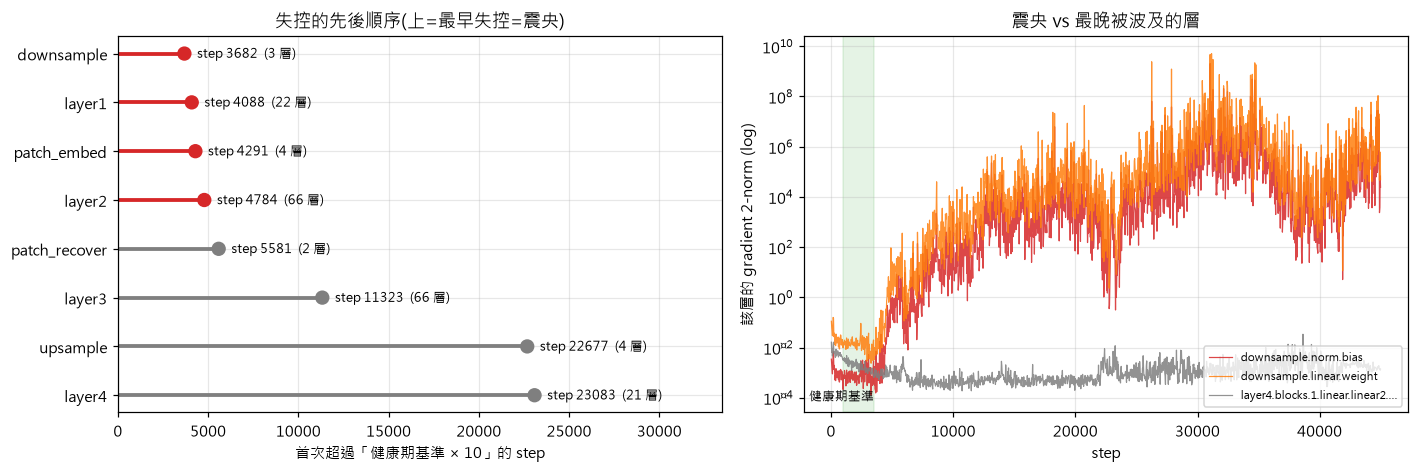

=== 最早失控的 8 層(震央)===
    首次超標step       健康期中位        全程最大  層
        3682   0.0006859   2.039e+09  downsample.norm.bias
        3682   0.0005608   3.858e+09  downsample.norm.weight
        3972     0.01346   5.109e+09  downsample.linear.weight
        3972   0.0002807   1.326e+06  layer2.blocks.0.norm1.bias
        3972   0.0002803   9.401e+06  layer2.blocks.0.norm1.weight
        3972   0.0002318   1.354e+06  layer2.blocks.0.norm2.bias
        3972   0.0002051    5.33e+06  layer2.blocks.0.norm2.weight
        3972    0.003381   7.566e+05  layer2.blocks.1.attention.proj.weight

=== 依模組:首次超標 step 的中位數(由早到晚)===
   downsample     step   3682   (3 層)
   layer1         step   4088   (22 層)
   patch_embed    step   4291   (4 層)
   layer2         step   4784   (66 層)
   patch_recover  step   5582   (2 層)
   layer3         step  11324   (66 層)
   upsample       step  22677   (4 層)
   layer4         step  23083   (21 層)

188 / 191 層最終都被波及。
資料流:patch_embed → layer1 → downsample → layer2 → layer3

In [21]:
import gzip

# 逐層梯度每步都記錄(191 層 × 3,620 點),原始 CSV 46 MB,
# 故只保留 step <= 45,000(所有「首次超標」事件都在此之前)並壓縮。
lay = {}
with gzip.open("run_mine_per_layer.csv.gz", "rt", newline="") as f:
    for r in csv.DictReader(f):
        lay.setdefault(r["tag"].replace("grad_2.0_norm/", ""), []).append(
            (int(r["step"]), float(r["value"])))
for p in lay.values():
    p.sort()

BASE_LO, BASE_HI, FACTOR = 1000, 3500, 10      # 健康期區間、判定倍數

first = []
for name, p in lay.items():
    base = [v for s, v in p if BASE_LO <= s <= BASE_HI]
    if len(base) < 5:
        continue
    b = np.median(base)
    if b <= 0:
        continue
    hit = [s for s, v in p if s > BASE_HI and v > FACTOR * b]
    if hit:
        first.append((hit[0], name, b, max(v for _, v in p)))
first.sort()


def group(n):
    for k in ("patch_embed", "downsample", "upsample", "layer1", "layer2",
              "layer3", "layer4", "patch_recover"):
        if k in n:
            return k
    return "其他"


by = {}
for s, n, _, _ in first:
    by.setdefault(group(n), []).append(s)
# y 軸依【失控先後】排序,由早到晚 —— 直接讀就是傳染順序
by = dict(sorted(by.items(), key=lambda x: np.median(x[1])))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

# 左:什麼時候失控(lollipop,越靠左越早)
names = list(by)[::-1]
med = [np.median(by[k]) for k in names]
cols = ["tab:red" if m < 5000 else "tab:gray" for m in med]
ax[0].hlines(names, 0, med, color=cols, lw=2.5)
ax[0].scatter(med, names, color=cols, s=70, zorder=5)
for i, (k, m) in enumerate(zip(names, med)):
    ax[0].text(m + 700, i, "step %d  (%d 層)" % (m, len(by[k])),
               va="center", fontsize=8.5)
ax[0].set_xlim(0, max(med) * 1.45)
ax[0].set_xlabel("首次超過「健康期基準 × %d」的 step" % FACTOR)
ax[0].set_title("失控的先後順序(上=最早失控=震央)")

# 右:震央那幾層 vs 最晚被波及的那層,實際的梯度曲線
show = [first[0][1], first[2][1],
        max(first, key=lambda x: x[0])[1]]
for n, c in zip(show, ["tab:red", "tab:orange", "tab:gray"]):
    s = np.array([x[0] for x in lay[n]])
    v = np.array([x[1] for x in lay[n]])
    ax[1].semilogy(s, v, lw=.8, c=c, alpha=.85,
                   label=n if len(n) < 34 else n[:31] + "...")
ax[1].axvspan(BASE_LO, BASE_HI, color="tab:green", alpha=.12)
ax[1].annotate("健康期基準", (BASE_HI, ax[1].get_ylim()[0] * 3),
               fontsize=8.5, ha="right")
ax[1].set_xlabel("step")
ax[1].set_ylabel("該層的 gradient 2-norm (log)")
ax[1].set_title("震央 vs 最晚被波及的層")
ax[1].legend(fontsize=7.5, loc="lower right")

plt.tight_layout()
plt.show()


print("=== 最早失控的 8 層(震央)===")
print("%12s %11s %11s  %s" % ("首次超標step", "健康期中位", "全程最大", "層"))
for s, n, b, mx in first[:8]:
    print("%12d %11.4g %11.4g  %s" % (s, b, mx, n))

print("\n=== 依模組:首次超標 step 的中位數(由早到晚)===")
for k, v in by.items():
    print("   %-14s step %6.0f   (%d 層)" % (k, np.median(v), len(v)))

print("\n%d / %d 層最終都被波及。" % (len(first), len(lay)))
print("資料流:patch_embed → layer1 → downsample → layer2 → layer3 "
      "→ upsample → layer4 → patch_recover")
print("       └───────────────── U-Net skip:layer1 直達 layer4 ──────────────┘")

---

# 網格與算力(不依賴訓練資料的幾何事實)

以下四張圖不需要任何訓練結果,純粹由網格設定推導 —— 適合放在簡報的**前半段**,
先讓聽眾理解「極座標到底改了什麼」,再進到訓練與診斷。

## 圖 8:三種網格的幾何對照

同樣的 20°×20° 範圍(虛線方框),三種取樣方式。虛線圓是極座標實際覆蓋的
`r ≤ 10°` 區域 —— **方框四角落在圓外,那 21.5% 的面積極座標並未涵蓋**。

> ⚠️ **這張圖會揭穿一個容易講錯的宣稱**:相對原版笛卡兒,極座標的**格點數其實更多**
> (7,380 vs 6,561,多 12%)。token 少 2.33× 是因為 patch 從 4×4 放大到 8×6,
> 而放大 patch 在笛卡兒下也做得到。**真正屬於極座標的節省是相對學姊 R=201 的 4.33×。**

In [ ]:
import math

# (名稱, 徑向格數, 方位格數, patch_r, patch_θ, 顏色)
GRIDS = [("原版笛卡兒\n81×81, Δ 0.25°", 81, 81, 4, 4, "tab:blue"),
         ("學姊極座標\nR=201 (Δr 0.05°), Θ=180", 201, 180, 8, 6, "tab:purple"),
         ("本次極座標\nR=41 (Δr 0.25°), Θ=180", 41, 180, 8, 6, "tab:red")]
NZ = 8                                    # 垂直方向的 token 數(三者相同)

fig, ax = plt.subplots(1, 3, figsize=(14, 5.2))

for k, (name, A, B, pa, pb, col) in enumerate(GRIDS):
    a = ax[k]
    npad_a = math.ceil(A / pa) * pa - A    # 該軸為了整除而零填充的格數

    if k == 0:                            # ── 笛卡兒 ──
        half = (A - 1) / 2 * 0.25          # = 10°
        # patch 邊界只畫在【真實資料範圍內】。81 不被 4 整除,最後一塊
        # 靠零填充補齊(見下方輸出),不畫到框外以免誤解為資料。
        edges = np.clip((np.arange(0, A + pa, pa) - (A - 1) / 2) * 0.25, -half, half)
        edges = np.unique(edges)
        for e in edges:
            a.plot([e, e], [-half, half], c=col, lw=.7, alpha=.9)
            a.plot([-half, half], [e, e], c=col, lw=.7, alpha=.9)
        gs = (np.arange(0, A, 4) - (A - 1) / 2) * 0.25
        X, Y = np.meshgrid(gs, gs)
        a.scatter(X, Y, s=1.2, c=col, alpha=.30, linewidths=0)
        ntok = NZ * math.ceil(A / pa) * math.ceil(B / pb)
        sub = "patch 4×4 格 → %d×%d token" % (math.ceil(A / pa), math.ceil(B / pb))
    else:                                 # ── 極座標 ──
        rr = np.linspace(0, 10, A)
        Rp, Tp = np.meshgrid(rr[::4],
                             np.linspace(0, 2 * np.pi, B, endpoint=False)[::6],
                             indexing="ij")
        a.scatter(Rp * np.cos(Tp), Rp * np.sin(Tp), s=1.2, c=col, alpha=.30,
                  linewidths=0)
        th = np.linspace(0, 2 * np.pi, 361)
        n_ring, n_spoke = math.ceil(A / pa), B // pb
        for i in range(n_ring + 1):        # 同心圓 = 徑向 patch 邊界
            rad = min(i * pa, A - 1) / (A - 1) * 10
            a.plot(rad * np.cos(th), rad * np.sin(th), c=col, lw=.7, alpha=.9)
        for j in range(n_spoke):           # 放射線 = 方位 patch 邊界
            t = 2 * np.pi * j / n_spoke
            a.plot([0, 10 * np.cos(t)], [0, 10 * np.sin(t)], c=col, lw=.7, alpha=.9)
        ntok = NZ * n_ring * n_spoke
        sub = "patch 8環×6向 → %d環×%d扇 token" % (n_ring, n_spoke)

    a.add_patch(plt.Rectangle((-10, -10), 20, 20, fill=False, ec="k",
                              lw=1.3, ls="--",
                              label="資料範圍 20°×20°" if k == 0 else None))
    a.set_aspect("equal")
    a.set_xlim(-11.5, 11.5); a.set_ylim(-11.5, 11.5)
    a.set_xlabel("距中心經度方向(度)")
    a.grid(False)
    a.set_title("%s\n%s\n格點 %s   token %s   零填充 %d 格"
                % (name, sub, f"{A * B:,}", f"{ntok:,}", npad_a), fontsize=9)
ax[0].set_ylabel("距中心緯度方向(度)")
ax[0].legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()


print("黑色虛線框 = 資料實際涵蓋的 20°×20°(±10°)範圍,三張圖都一樣。")
print("細線 = patch(token)邊界,每一塊就是 transformer 的一個 token。")
print("淡點 = 底層格點(已抽稀顯示,實際密度見下表)。\n")

print("%-26s %10s %10s %10s %s" % ("", "格點數", "token 數", "patch 格數", "零填充"))
print("-" * 78)
tok = lambda A, B, pa, pb: NZ * math.ceil(A / pa) * math.ceil(B / pb)
for name, A, B, pa, pb, _ in GRIDS:
    print("%-26s %10s %10s %10d   第一軸 %d 格 / 第二軸 %d 格"
          % (name.replace("\n", " "), f"{A * B:,}", f"{tok(A, B, pa, pb):,}",
             pa * pb, math.ceil(A / pa) * pa - A, math.ceil(B / pb) * pb - B))

print("\n⚠️ 零填充是【真實存在】的,不是畫圖失誤:")
print("   笛卡兒 81 不被 4 整除 → 補到 84,兩軸各 3 格是零(靠 pad_mask 蓋掉)")
print("   極座標 R=41 不被 8 整除 → 補到 48,徑向 7 格是零")
print("   極座標 Θ=180 【被 6 整除】→ 方位【零填充】,這正是極座標規則②的要求")
print("   (θ 是週期軸,補零會製造假的接縫;整除就完全不用補)")

c, s_, m = tok(81, 81, 4, 4), tok(201, 180, 8, 6), tok(41, 180, 8, 6)
print("\n本次 vs 學姊  : token 少 %.2f×   格點少 %.2f×   ← 真正的算力節省"
      % (s_ / m, 201 * 180 / (41 * 180)))
print("本次 vs 笛卡兒: token 少 %.2f×   格點【多】%.0f%%"
      % (c / m, (41 * 180 / (81 * 81) - 1) * 100))

print("\n⚠️ 必須誠實說明的一點:")
print("   相對【原版笛卡兒】,極座標的格點數其實【多了 12%】(7,380 vs 6,561)。")
print("   token 之所以少,是因為 patch 從 4×4=16 格放大到 8×6=48 格(3 倍),")
print("   而【放大 patch 在笛卡兒座標下也做得到】—— 這一項不是極座標的功勞。")
print("\n   極座標真正帶來的是:")
print("     (a) 相對學姊那個過度取樣的 R=201 網格,省下 4.33× token")
print("     (b) 網格與物理對齊(vt/vr 直接是切向/徑向風)")
print("     (c) 取樣密度自動集中在內核(見圖 11)")
print("\n   另注意:虛線方框的四角在極座標圓之外 —— 那 21.5% 的面積未被涵蓋(見圖 13)。")

## 圖 9:精度 × 學習率 —— 一張圖講完全部診斷

五組短診斷把「一次改五項、無法歸因」拆成單變數對照。結論收斂成這個矩陣:

- **同一列**比較 = 只改學習率
- **同一行**比較 = 只改精度(`診斷A` vs `診斷C` vs `診斷D` 排程完全相同)

> **兩種 16-bit 從相反方向失敗** —— 這是本次最乾淨的一個發現:
> `bf16`(指數 8、尾數 8)範圍夠但精度不足 ⇒ 誤差**漸進**累積,梯度爬到 1.1e4;
> `fp16`(指數 5、尾數 11)精度夠但範圍不足 ⇒ step 6,321 **突然**溢位成 NaN。
>
> 所以正確的敘述不是「混合精度不能用」,而是 **「16 bits 不夠用」**。

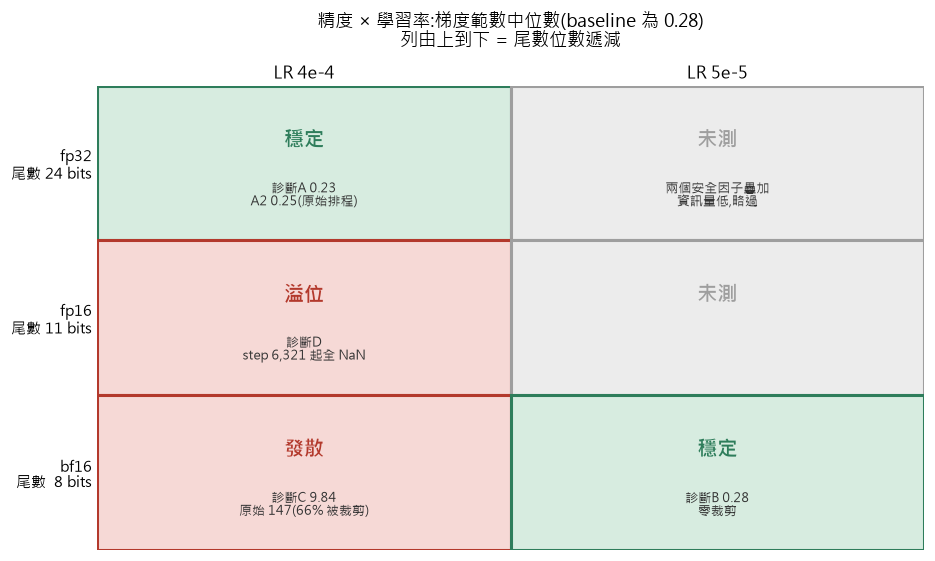

兩種 16-bit 從【相反方向】失敗:
  bf16  指數 8 bits(同 fp32)、尾數 8 bits  → 範圍夠、精度不足
        ⇒ 捨入誤差【漸進】累積,梯度從 0.20 爬到 1.1e4
  fp16  指數 5 bits、尾數 11 bits            → 精度夠、範圍不足
        ⇒ step 6,321【突然】溢位成 NaN,權重直接損壞

⇒ 這不是『混合精度不能用』,是【16 bits 不夠用】——
  兩種分配方式(換範圍 / 換精度)在這個模型上都各自撞牆。

可用的兩條路,機制不同:
  fp32 + 4e-4   移除成因(精度足夠)         實測 10,574 步/時
  bf16 + 5e-5   減緩累積(步幅小、誤差累積慢) 實測 15,283 步/時,長跑未驗證


In [27]:
# 每格:(狀態, 標題行, 明細行)。狀態同時決定顏色【和】符號 —— 不靠顏色單獨編碼。
#   OK = 梯度維持 O(1) | BAD = 發散或 NaN | NA = 未測
CELLS = {
    ("fp32\n尾數 24 bits", "LR 4e-4"): ("OK",  "穩定",
                                        "診斷A 0.23\nA2 0.25(原始排程)"),
    ("fp32\n尾數 24 bits", "LR 5e-5"): ("NA",  "未測",
                                        "兩個安全因子疊加\n資訊量低,略過"),
    ("fp16\n尾數 11 bits", "LR 4e-4"): ("BAD", "溢位",
                                        "診斷D\nstep 6,321 起全 NaN"),
    ("fp16\n尾數 11 bits", "LR 5e-5"): ("NA",  "未測", ""),
    ("bf16\n尾數  8 bits", "LR 4e-4"): ("BAD", "發散",
                                        "診斷C 9.84\n原始 147(66% 被裁剪)"),
    ("bf16\n尾數  8 bits", "LR 5e-5"): ("OK",  "穩定",
                                        "診斷B 0.28\n零裁剪"),
}
FACE = {"OK": "#d7ece0", "BAD": "#f6d9d6", "NA": "#ececec"}
EDGE = {"OK": "#2e7d5b", "BAD": "#b3392c", "NA": "#9e9e9e"}

rows = ["fp32\n尾數 24 bits", "fp16\n尾數 11 bits", "bf16\n尾數  8 bits"]
cols = ["LR 4e-4", "LR 5e-5"]

fig, ax = plt.subplots(figsize=(8.6, 5.2))
for i, rname in enumerate(rows):
    for j, cname in enumerate(cols):
        st, head, detail = CELLS[(rname, cname)]
        ax.add_patch(plt.Rectangle((j, -i - 1), 1, 1, facecolor=FACE[st],
                                   edgecolor=EDGE[st], lw=2))
        ax.text(j + .5, -i - .34, head, ha="center", va="center",
                fontsize=13, fontweight="bold", color=EDGE[st])
        if detail:
            ax.text(j + .5, -i - .70, detail, ha="center", va="center",
                    fontsize=8.5, color="#333333")

ax.set_xlim(0, len(cols)); ax.set_ylim(-len(rows), 0)
ax.set_xticks(np.arange(len(cols)) + .5); ax.set_xticklabels(cols, fontsize=11)
ax.set_yticks(-np.arange(len(rows)) - .5); ax.set_yticklabels(rows, fontsize=10)
ax.xaxis.set_ticks_position("top")
ax.tick_params(length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.grid(False)
ax.set_title("精度 × 學習率:梯度範數中位數(baseline 為 0.28)\n"
             "列由上到下 = 尾數位數遞減", pad=26, fontsize=11.5)
plt.tight_layout()
plt.show()


print("兩種 16-bit 從【相反方向】失敗:")
print("  bf16  指數 8 bits(同 fp32)、尾數 8 bits  → 範圍夠、精度不足")
print("        ⇒ 捨入誤差【漸進】累積,梯度從 0.20 爬到 1.1e4")
print("  fp16  指數 5 bits、尾數 11 bits            → 精度夠、範圍不足")
print("        ⇒ step 6,321【突然】溢位成 NaN,權重直接損壞")
print("\n⇒ 這不是『混合精度不能用』,是【16 bits 不夠用】——")
print("  兩種分配方式(換範圍 / 換精度)在這個模型上都各自撞牆。")
print("\n可用的兩條路,機制不同:")
print("  fp32 + 4e-4   移除成因(精度足夠)         實測 10,574 步/時")
print("  bf16 + 5e-5   減緩累積(步幅小、誤差累積慢) 實測 15,283 步/時,長跑未驗證")

## 圖 10:80× 吞吐從哪裡來 —— 可分解驗證

喊「快了 80 倍」沒有說服力,**能把它拆開、而且乘起來對得上**才有。
每一項都是獨立可驗證的:

```
8 卡 DDP (8×) × 16-bit 精度 (2×) × 網格 R=201→41 (4.33×) × 移除死 bias (1.18×) ≈ 81×
```

實測 **80×**,與估計吻合 ⇒ 各項貢獻的歸因是正確的。

> ⚠️ **誠實標註**:其中「16-bit 精度 2×」後來證實**不能用 bf16 拿**(圖 5:bf16 發散、
> fp16 溢位成 NaN)。改回 fp32 後約慢 1.45×,**真正可保留的加速約 55×**。
> 簡報講 80× 時必須一併講這件事,否則就是誇大。

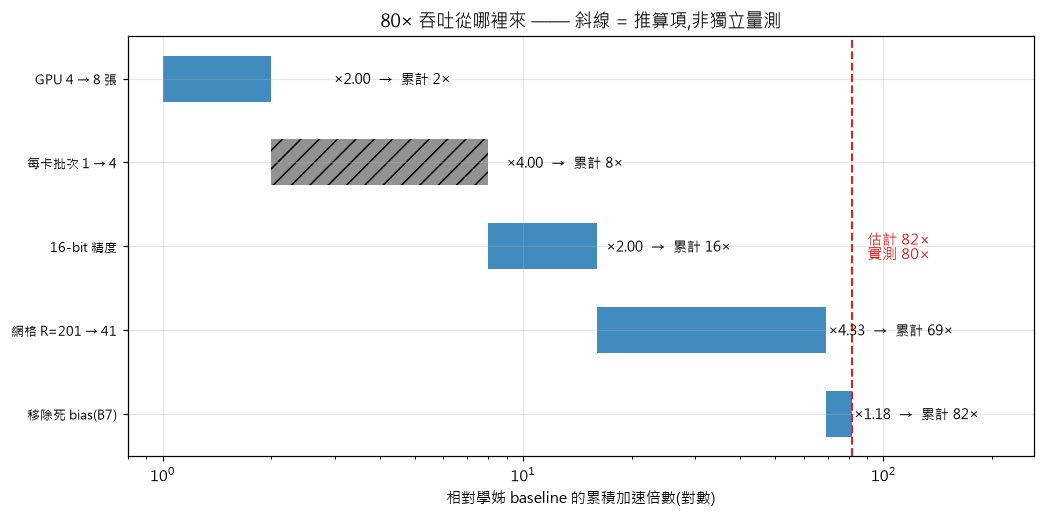

項目                           倍數     來源  說明
----------------------------------------------------------------------------------
GPU 4 → 8 張               2.00×     實測  直接可查:她 4 卡,我 8 卡
每卡批次 1 → 4                4.00×     推算  殘差項(80 ÷ 其他三項)—— 非獨立量測
16-bit 精度                 2.00×     實測  bf16(⚠️ 後證實會發散,見圖 5/9)
網格 R=201 → 41             4.33×     實測  token 6,240 → 1,440
移除死 bias(B7)              1.18×     實測  輸出 bit-identical
----------------------------------------------------------------------------------
累計                          82×  (實測 80×)

⚠️ 更正:先前寫『學姊那次等效只用了 1 卡』是【錯的】。
   當時的依據是 steps/epoch:學姊 3,625、本次 454。但這個數字只能推出
       等效批次 = 14,528 / 3,625 ≈ 4
   而『4 卡 × 每卡批次 1』和『1 卡 × 批次 4』會給出【完全相同】的 4,
   steps/epoch 無法區分兩者。學姊本人說明是 4 卡,且其 config 的
   batch_size = 1 ⇒ 4 × 1 = 4,【DDP 是正常運作的】。

   所以 GPU 張數只貢獻 2×(4→8),另外的 4× 來自每卡批次 1→4
   (批次 1 會讓 H200 嚴重閒置)。兩者相乘仍是 8×,總數不變,但歸因不同。

⚠️ 另外兩點限制:
   1.『每卡批次 4×』是用總數回推的殘差,不是獨立量測(圖中以斜線標示)。
   2. 學姊使用的 GPU 型號未知,若非 H200 則機器差異也混在裡面。

⚠️ 且『16-bit 精度 2×』

In [26]:
# ⚠️ 更正(2026-08-05):原本把整個 8× 都算在「8 卡 DDP」上,並宣稱學姊那次
#    「等效只用了 1 卡」。那個推論【錯了】—— 見本 cell 最後的說明。
#    正確拆法是把 GPU【張數】和【每卡批次】分開。
STEPS = [("基準\n學姊 4 卡 fp32 R=201\n每卡批次 1", 1.0, None, True),
         ("GPU 4 → 8 張", 2.00, "直接可查:她 4 卡,我 8 卡", True),
         ("每卡批次 1 → 4", 4.00, "殘差項(80 ÷ 其他三項)—— 非獨立量測", False),
         ("16-bit 精度", 2.00, "bf16(⚠️ 後證實會發散,見圖 5/9)", True),
         ("網格 R=201 → 41", 4.33, "token 6,240 → 1,440", True),
         ("移除死 bias(B7)", 1.18, "輸出 bit-identical", True)]

cum, labels, widths, lefts, solid = 1.0, [], [], [], []
for name, f, _, sd in STEPS[1:]:
    lefts.append(cum); cum *= f
    widths.append(cum - lefts[-1]); labels.append(name); solid.append(sd)

fig, ax = plt.subplots(figsize=(9.6, 4.8))
y = np.arange(len(labels))[::-1]
ax.barh(y, widths, left=lefts, height=.55,
        color=["tab:blue" if s else "tab:gray" for s in solid],
        alpha=.85, hatch=[None if s else "//" for s in solid])
for yy, l, w, f in zip(y, lefts, widths, [s[1] for s in STEPS[1:]]):
    ax.text(l + w + cum * .012, yy, "×%.2f  →  累計 %.0f×" % (f, l + w),
            va="center", fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xscale("log"); ax.set_xlim(0.8, cum * 3.2)
ax.set_xlabel("相對學姊 baseline 的累積加速倍數(對數)")
ax.set_title("80× 吞吐從哪裡來 —— 斜線 = 推算項,非獨立量測")
ax.axvline(cum, c="tab:red", ls="--", lw=1.4)
ax.annotate("估計 %.0f×\n實測 80×" % cum, (cum, y.mean()),
            xytext=(10, 0), textcoords="offset points",
            fontsize=9.5, color="tab:red", va="center")
plt.tight_layout()
plt.show()


print("%-22s %8s %6s  %s" % ("項目", "倍數", "來源", "說明"))
print("-" * 82)
acc = 1.0
for name, f, note, sd in STEPS[1:]:
    acc *= f
    print("%-22s %7.2f× %6s  %s" % (name.replace("\n", " "), f,
                                    "實測" if sd else "推算", note or ""))
print("-" * 82)
print("%-22s %7.0f×  (實測 80×)" % ("累計", acc))

print("\n⚠️ 更正:先前寫『學姊那次等效只用了 1 卡』是【錯的】。")
print("   當時的依據是 steps/epoch:學姊 3,625、本次 454。但這個數字只能推出")
print("       等效批次 = 14,528 / 3,625 ≈ 4")
print("   而『4 卡 × 每卡批次 1』和『1 卡 × 批次 4』會給出【完全相同】的 4,")
print("   steps/epoch 無法區分兩者。學姊本人說明是 4 卡,且其 config 的")
print("   batch_size = 1 ⇒ 4 × 1 = 4,【DDP 是正常運作的】。")
print("\n   所以 GPU 張數只貢獻 2×(4→8),另外的 4× 來自每卡批次 1→4")
print("   (批次 1 會讓 H200 嚴重閒置)。兩者相乘仍是 8×,總數不變,但歸因不同。")
print("\n⚠️ 另外兩點限制:")
print("   1.『每卡批次 4×』是用總數回推的殘差,不是獨立量測(圖中以斜線標示)。")
print("   2. 學姊使用的 GPU 型號未知,若非 H200 則機器差異也混在裡面。")
print("\n⚠️ 且『16-bit 精度 2×』後來證實拿不到(圖 9)。改回 fp32 後實測")
print("   10,574 步/時 vs bf16 的 15,283 步/時 ⇒ 真正可保留的加速約 55×。")

## 圖 11:取樣密度隨半徑變化 —— 極座標的代價與 loss 加權的依據

極座標每一環都有 **180 個格點**,不論半徑。所以相鄰格點的方位間距是 `r × Δθ`
—— **中心附近極密、外圍極疏**。這一張同時解釋三件事:

1. 為什麼**壞值只出現在最外緣**(該處取樣最疏、每格代表的面積最大、被約束最少)
2. 為什麼「均勻 loss」在極座標下**已經偏重內核**(每單位面積的權重 ∝ 1/r)
3. 空間權重 `w(r) = r^p` 的 **p 該取多少**(⚠️ 取 p=1 等面積會**抵銷**老師的目標②)

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

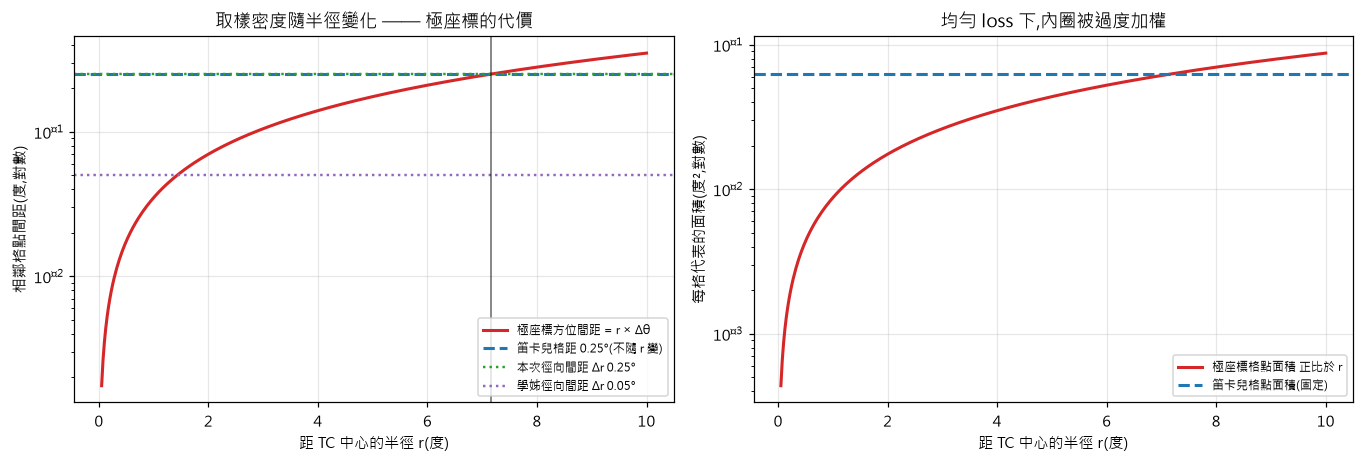

方位間距 = r × Δθ,Δθ = 2°
    r(度)        方位間距(度)  相對笛卡兒 0.25°
    0.25         0.0087  密 28.6×
    1.00         0.0349  密 7.2×
    2.00         0.0698  密 3.6×
    5.00         0.1745  密 1.4×
    7.16         0.2499  密 1.0×
   10.00         0.3491  疏 1.4×

最內圈 vs 最外圈的面積比 = 40 倍
⇒ 均勻(不加權)loss 下,【每單位物理面積】的權重 ∝ 1/r,
   最外圈是全網格中最少被約束的區域 —— 與觀察到的『壞值只在最外緣』一致。

注意方向:老師的目標②是【增加內核關注度】,而均勻權重【已經】偏重內核。
      若加 w(r)=r 做等面積加權,反而會【抵銷】目標② ⇒ p 應介於 0~0.5。


In [25]:
DTHETA = 2 * np.pi / 180          # Θ=180 ⇒ Δθ = 2°
CART_DX = 0.25                    # 笛卡兒格距(度)
r = np.linspace(0.05, 10, 400)
azim = r * DTHETA                 # 方位間距 = r × Δθ(度)
r_cross = CART_DX / DTHETA

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3))

# 左:方位間距 vs 半徑
ax[0].plot(r, azim, c="tab:red", lw=2, label="極座標方位間距 = r × Δθ")
ax[0].axhline(CART_DX, c="tab:blue", lw=2, ls="--", label="笛卡兒格距 0.25°(不隨 r 變)")
ax[0].axhline(0.25, c="tab:green", lw=1.6, ls=":", label="本次徑向間距 Δr 0.25°")
ax[0].axhline(0.05, c="tab:purple", lw=1.6, ls=":", label="學姊徑向間距 Δr 0.05°")
ax[0].axvline(r_cross, c="k", lw=1, alpha=.6)
ax[0].annotate("交叉點 r = %.2f°\n內側比笛卡兒密,外側比笛卡兒疏" % r_cross,
               (r_cross, 0.5), xytext=(-8, 0), textcoords="offset points",
               ha="right", fontsize=8.5)
ax[0].set_yscale("log")
ax[0].set_xlabel("距 TC 中心的半徑 r(度)")
ax[0].set_ylabel("相鄰格點間距(度,對數)")
ax[0].set_title("取樣密度隨半徑變化 —— 極座標的代價")
ax[0].legend(fontsize=8, loc="lower right")

# 右:每個格點代表的物理面積 vs 半徑(等面積 loss 加權的依據)
area_polar = r * DTHETA * 0.25                    # r·Δθ·Δr
ax[1].plot(r, area_polar, c="tab:red", lw=2, label="極座標格點面積 正比於 r")
ax[1].axhline(CART_DX ** 2, c="tab:blue", lw=2, ls="--", label="笛卡兒格點面積(固定)")
ax[1].set_yscale("log")
ax[1].set_xlabel("距 TC 中心的半徑 r(度)")
ax[1].set_ylabel("每格代表的面積(度²,對數)")
ax[1].set_title("均勻 loss 下,內圈被過度加權")
ax[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()


print("方位間距 = r × Δθ,Δθ = 2°")
print("%8s %14s  %s" % ("r(度)", "方位間距(度)", "相對笛卡兒 0.25°"))
for rr in (0.25, 1, 2, 5, 7.16, 10):
    a = rr * DTHETA
    print("%8.2f %14.4f  %s" % (rr, a, "密 %.1f×" % (CART_DX / a) if a < CART_DX
                                else "疏 %.1f×" % (a / CART_DX)))
print("\n最內圈 vs 最外圈的面積比 = %.0f 倍" % (10 / 0.25))
print("⇒ 均勻(不加權)loss 下,【每單位物理面積】的權重 ∝ 1/r,")
print("   最外圈是全網格中最少被約束的區域 —— 與觀察到的『壞值只在最外緣』一致。")
print("\n注意方向:老師的目標②是【增加內核關注度】,而均勻權重【已經】偏重內核。")
print("      若加 w(r)=r 做等面積加權,反而會【抵銷】目標② ⇒ p 應介於 0~0.5。")

---

# 內插與耦合(推論端的機制)

## 圖 12:雙線性內插怎麼做的,以及 **r=0 奇點**

`latlon_to_polar` 對每個 `(r, θ)` 目標點算出它在笛卡兒網格上的座標
`x = cx + r·cosθ`、`y = cy + r·sinθ`,再用 `map_coordinates(order=1)` 做雙線性內插。

**問題出在 `r = np.linspace(0, r_max, R)` 的第一個值是 0。**
`r = 0` 時,不論 θ 是多少,`(x, y)` 永遠等於 `(cx, cy)` ——
**180 個方位索引到同一個笛卡兒格點**,於是最內環 180 個值完全相同。

右圖用一個答案已知的合成場 `f(x,y) = x`(轉到極座標應為 `r·cosθ`)驗證:
第 0 環是一條**完全水平**的線,其餘各環的振幅正比於 `r`。

In [ ]:
from scipy.ndimage import map_coordinates

R, THETA, R_MAX = 41, 180, 10.0     # 與 config 相同
CX = CY = 40.0                      # 81×81 的中心格點索引
CELL = 0.25                         # 度/格

# 合成場:f(x, y) = x —— 例如「背景東風對切向風的貢獻」,轉到極座標就是 r·cosθ。
# 用它是因為【答案已知】:第 i 環的值應該是 r_i·cos(θ),振幅正比於 r_i。
ii = np.arange(81)
Xc, Yc = np.meshgrid((ii - CX) * CELL, (ii - CY) * CELL)
field = Xc                                        # (81, 81)

# 完全照 latlon_to_polar 的做法(DLAMPty_inference.py:43-67)
r_axis = np.linspace(0, R_MAX, R) / CELL          # 注意:【從 0 開始】
t_axis = np.linspace(0, 2 * np.pi, THETA, endpoint=False)
RR, TT = np.meshgrid(r_axis, t_axis, indexing="ij")
xs, ys = CX + RR * np.cos(TT), CY + RR * np.sin(TT)
polar = map_coordinates(field, np.array([ys, xs]), order=1, mode="constant")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# ── 左:取樣點落在哪裡(放大到中心 ±1°)──────────────────────────────
a = ax[0]
gg = (np.arange(33, 48) - CX) * CELL
GX, GY = np.meshgrid(gg, gg)
a.scatter(GX, GY, s=26, c="lightgray", marker="s", label="笛卡兒格點(0.25°)")
for i, lbl in [(0, None), (1, None), (2, None), (3, None), (4, None)]:
    rd = r_axis[i] * CELL
    a.scatter(rd * np.cos(t_axis), rd * np.sin(t_axis), s=13,
              c="tab:red" if i == 0 else "tab:blue",
              zorder=5 if i == 0 else 4,
              label=("第 0 環:180 點【全部重合在中心】" if i == 0 else
                     ("第 1–4 環(每環 180 點)" if i == 1 else None)))
a.set_aspect("equal"); a.set_xlim(-1.05, 1.05); a.set_ylim(-1.05, 1.05)
a.grid(False)
a.set_xlabel("距中心(度)"); a.set_ylabel("距中心(度)")
a.set_title("內插取樣點(放大到中心 ±1°)\nΔr = %.2f°,而中心格距 0.25°" % (R_MAX / (R - 1)))
a.legend(fontsize=8, loc="upper right")

# ── 右:各環的值隨 θ 變化 ─────────────────────────────────────────────
a = ax[1]
for i, c in [(0, "tab:red"), (1, "tab:blue"), (2, "tab:green"),
             (5, "tab:orange"), (10, "tab:purple")]:
    a.plot(np.rad2deg(t_axis), polar[i], c=c, lw=1.8 if i == 0 else 1.2,
           label="第 %d 環 (r = %.2f°)%s"
                 % (i, r_axis[i] * CELL, "  ← 完全水平" if i == 0 else ""))
a.set_xlabel("方位角 θ(度)"); a.set_ylabel("內插後的值")
a.set_title("同一環上,值隨 θ 怎麼變")
a.legend(fontsize=8)

plt.tight_layout()
plt.show()


print("=== 為什麼最內環 180 個格點的值完全相同 ===")
print("latlon_to_polar 用  r = np.linspace(0, r_max, R)  ——【第一個值就是 0】。")
print("而取樣座標是  x = cx + r·cosθ,  y = cy + r·sinθ。")
print("r = 0 時,不管 θ 是多少,(x, y) 永遠等於 (cx, cy) = (%.0f, %.0f)。" % (CX, CY))
print("⇒ 180 個方位【索引到同一個笛卡兒格點】,插出來當然是同一個數。\n")
print("%6s %10s %14s %14s" % ("環", "r(度)", "沿 θ 的標準差", "沿 θ 的最大-最小"))
print("-" * 50)
for i in (0, 1, 2, 5, 10, 20, 40):
    print("%6d %10.3f %14.6g %14.6g"
          % (i, r_axis[i] * CELL, polar[i].std(), np.ptp(polar[i])))

print("\n第 0 環標準差 = %.3g(數值上就是 0)⇒ 這一環【沒有攜帶任何方位資訊】。"
      % polar[0].std())
print("其餘各環振幅正比於 r,符合 f = r·cosθ 的預期 ⇒ 內插本身是正確的。")

print("\n=== 為什麼這對 vt/vr 特別糟 ===")
print("純量(氣溫、氣壓)在中心點本來就只有一個值,r=0 全部相同【物理上合理】。")
print("但切向風 vt 的【方向定義本身就依賴 θ】—— 同一個物理風向量,在 θ=0° 是")
print("純徑向、在 θ=90° 是純切向。所以 vt 在 r→0 時應隨 θ 作正弦變化,")
print("而 r=0 這一環卻被灌成常數 ⇒ 目標場自相矛盾,模型被要求學一個不可能的東西。")

print("\n=== 修法 ===")
print("  r = np.linspace(r_min, r_max, R),取 r_min = Δr/2 = %.3f°" % (R_MAX / (R - 1) / 2))
print("  ⇒ 最內環退到半格外,180 個方位落在不同位置,奇點消失。")
print("  ⚠️ 訓練端與推論端【必須同時改】,否則兩邊網格定義不一致(§7 的 I8)。")
print("  影響範圍:41 環中的 1 環 = 2.4% 的格點。")

## 圖 13:耦合推論的空間分工 —— 誰負責哪一塊

一個 3 小時步進裡,同一個 81×81 框被切成好幾塊,各由不同來源負責。
這張圖也直接顯示 §7 的 **I5/I6** 兩個推論端缺陷發生在哪裡。

In [ ]:
R_MAX, N = 10.0, 81                 # 極座標半徑上限(度)、笛卡兒邊長
CELL = 0.25
BDY_CELLS = 8                       # one-way:最外 8 格由 FCNV2 取代
FEEDBACK_R = 7.5                    # two-way:此半徑內回饋給 FCNV2
half = (N - 1) / 2 * CELL           # = 10°

fig, ax = plt.subplots(1, 2, figsize=(12.5, 5.6))

# ── 左:一次推論步的空間分工 ──────────────────────────────────────────
a = ax[0]
bdy = half - BDY_CELLS * CELL       # = 8°
a.add_patch(plt.Rectangle((-half, -half), 2 * half, 2 * half,
                          fc="#fdecea", ec="none",
                          label="FCNV2 邊界置換(最外 %d 格,|x| 或 |y| > %g°)"
                                % (BDY_CELLS, bdy)))
a.add_patch(plt.Rectangle((-bdy, -bdy), 2 * bdy, 2 * bdy, fc="white", ec="none"))
th = np.linspace(0, 2 * np.pi, 400)
a.fill(R_MAX * np.cos(th), R_MAX * np.sin(th), fc="#e3eefb", ec="tab:blue",
       lw=1.4, zorder=1, label="LLAT 極座標輸出涵蓋範圍 r ≤ %g°" % R_MAX)
a.add_patch(plt.Rectangle((-bdy, -bdy), 2 * bdy, 2 * bdy, fc="none",
                          ec="tab:red", lw=1.2, ls="--", zorder=3))
a.fill(FEEDBACK_R * np.cos(th), FEEDBACK_R * np.sin(th), fc="#dff0e6",
       ec="tab:green", lw=1.6, zorder=2,
       label="two-way 回饋給 FCNV2(r ≤ %g°)" % FEEDBACK_R)
# 角落:圓外 → polar_to_latlon 的 fill_value = 0
for sx in (-1, 1):
    for sy in (-1, 1):
        t0 = np.linspace(0, np.pi / 2, 60)
        xs = np.concatenate([[sx * half], sx * R_MAX * np.cos(t0), [sx * half]])
        ys = np.concatenate([[sy * half], sy * R_MAX * np.sin(t0), [sy * half]])
        a.fill(xs, ys, fc="none", ec="tab:orange", hatch="xx", lw=1.1, zorder=4,
               label="圓外 → fill_value = 0(21.5% 格點)"
                     if (sx, sy) == (1, 1) else None)
a.add_patch(plt.Rectangle((-half, -half), 2 * half, 2 * half, fill=False,
                          ec="k", lw=1.4, ls="--", zorder=5))
a.set_aspect("equal"); a.set_xlim(-11.5, 11.5); a.set_ylim(-11.5, 11.5)
a.grid(False)
a.set_xlabel("距 TC 中心經度方向(度)"); a.set_ylabel("距 TC 中心緯度方向(度)")
a.set_title("耦合推論:一步之內誰負責哪一塊")
a.legend(fontsize=7.5, loc="upper center", bbox_to_anchor=(.5, -.13))

# ── 右:資料在一步之內的流動順序 ──────────────────────────────────────
a = ax[1]
a.axis("off")
BOXES = [(.5, .93, "FCNV2 全球場(0.25°)", "#e3eefb"),
         (.5, .78, "裁出 81×81 笛卡兒框(以 TC 為中心)", "#e3eefb"),
         (.5, .63, "latlon_to_polar\n雙線性內插 → (R=41, Θ=180)", "#fff4e0"),
         (.5, .48, "標準化 → LLAT 模型 → 反標準化", "#dff0e6"),
         (.5, .33, "polar_to_latlon\n圓外填 0 → 回到 81×81", "#fff4e0"),
         (.5, .18, "最外 8 格由 FCNV2 取代(one-way)\n+ r≤7.5° 回饋 FCNV2(two-way)",
          "#fdecea"),
         (.5, .03, "下一步:重新定中心,回到第 2 步", "#ececec")]
for x, y, t, fc in BOXES:
    a.add_patch(plt.Rectangle((x - .45, y - .055), .9, .11, fc=fc, ec="#666666",
                              lw=1, transform=a.transAxes, clip_on=False))
    a.text(x, y, t, ha="center", va="center", fontsize=8.8, transform=a.transAxes)
for y in [.855, .705, .555, .405, .255, .105]:
    a.annotate("", xy=(.5, y - .02), xytext=(.5, y + .02), xycoords=a.transAxes,
               arrowprops=dict(arrowstyle="-|>", lw=1.2, color="#666666"))
a.set_title("一個 3 小時步進的資料流")

plt.tight_layout()
plt.show()


inside = np.pi * R_MAX ** 2
box = (2 * half) ** 2
print("=== 面積帳(81×81 = 20°×20°)===")
print("  極座標圓 r ≤ %g°      %.1f%%   ← 模型實際輸出的區域" % (R_MAX, 100 * inside / box))
print("  圓外四角              %.1f%%   ← polar_to_latlon 填 0" % (100 * (1 - inside / box)))
print("  FCNV2 邊界帶(外 8 格) |x| 或 |y| > %g°" % bdy)
print("  two-way 回饋圓        r ≤ %g°  (完全落在極座標圓內,安全)" % FEEDBACK_R)

print("\n=== 兩個問題出在哪 ===")
print("(1) 角落 21.5% 被填 0 —— 這些格點【在 FCNV2 邊界帶內】,")
print("    所以會連同 0 值一起被送回 FCNV2。7.5° 回饋圓沒事,但邊界置換有事。")
print("(2) lonlat_uniformizer 從【含 21.5% 零值】的 lon/lat 場估中心")
print("    ⇒ 中心估計被拉偏,可能就是 +24h 中心差 350 km 的來源。")
print("\n修法(§7 的 I5/I6):fill_value 改 NaN + 下游遮罩,或把 r_max 放大到")
print("       %.1f° 讓極座標圓涵蓋整個方框(代價是外圈更稀疏,且需重新訓練)。"
      % (half * np.sqrt(2)))